## Rice Classification Model

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mssmartypants/rice-type-classification")

print("Path to dataset files:", path)

100%|██████████| 888k/888k [00:00<00:00, 95.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mssmartypants/rice-type-classification/versions/2


In [5]:
!pip install  opendatasets --quiet

import opendatasets as od

od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bharathvankayala
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 598MB/s]

In [6]:
import torch

import torch.nn as nn

from torch.optim import Adam

from torch.utils.data import Dataset , DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from torchsummary import summary

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


In [8]:
import os

data = pd.read_csv('/content/rice-type-classification/riceClassification.csv')

data.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [9]:
# dropping missing values
data = data.dropna()

data.drop(['id'] , axis = 1 , inplace = True)

print(f"Shape of DataSet : {data.shape}")

Shape of DataSet : (18185, 11)


In [10]:
print(data["Class"].unique)

print(data["Class"].value_counts())

<bound method Series.unique of 0        1
1        1
2        1
3        1
4        1
        ..
18180    0
18181    0
18182    0
18183    0
18184    0
Name: Class, Length: 18185, dtype: int64>
Class
1    9985
0    8200
Name: count, dtype: int64


In [11]:
original_data = data.copy()

for column in data.columns :

   data[column] = data[column]/data[column].abs().max()

In [12]:
print(data.head())

       Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  0.444368         0.503404         0.775435      0.744658    0.424873   
1  0.281293         0.407681         0.622653      0.750489    0.273892   
2  0.298531         0.416421         0.630442      0.756341    0.284520   
3  0.300979         0.420463         0.629049      0.764024    0.286791   
4  0.361704         0.464626         0.682901      0.775033    0.345385   

   EquivDiameter    Extent  Perimeter  Roundness  AspectRation  Class  
0       0.666610  0.741661   0.537029   0.844997      0.368316    1.0  
1       0.530370  0.804230   0.409661   0.919215      0.371471    1.0  
2       0.546380  0.856278   0.412994   0.959862      0.374747    1.0  
3       0.548616  0.883772   0.414262   0.961818      0.379222    1.0  
4       0.601418  0.867808   0.452954   0.966836      0.386007    1.0  


In [13]:
X = np.array(data.iloc[ : , : -1])

y = np.array(data.iloc[ :  , -1])

X_train , X_test , y_train , y_test = train_test_split(X , y, test_size = 0.3 , random_state = 42)

""" Spliting testing data into -> Validation set and testing data """

X_test , X_val , y_test , y_val = train_test_split(X_test , y_test , test_size = 0.5 , random_state = 42)

print(f"Shape of X_train : {X_train.shape}")

print(f"Shape of X_test : {X_test.shape}")

print(f"Shape of X_val : {X_val.shape}")

Shape of X_train : (12729, 10)
Shape of X_test : (2728, 10)
Shape of X_val : (2728, 10)


In [14]:
class dataset(Dataset):

  def __init__(self , X , y):

    self.X = torch.tensor(X , dtype = torch.float32).to(device)

    self.y = torch.tensor(y , dtype = torch.float32).to(device)

  def __len__(self):

    return len(self.X)

  def __getitem__(self , index):

    return self.X[index] , self.y[index]


In [15]:
training_data = dataset(X_train , y_train)

validation_data = dataset(X_val , y_val)

testing_data = dataset(X_test , y_test)

In [16]:
""" Creating DataLoader -> Loading data into batches """

train_dataloader = DataLoader(training_data , batch_size = 8 ,shuffle = True )

validation_dataloader = DataLoader(validation_data , batch_size = 8 , shuffle = True)

testing_dataloader = DataLoader(testing_data , batch_size = 8 , shuffle = True)



In [17]:
class MyModel(nn.Module):

  def  __init__(self):

    super(MyModel , self).__init__()

    self.input_layer = nn.Linear(X.shape[1] , out_features = 10)

    self.linear = nn.Linear(in_features = 10 , out_features = 1)

    self.sigmoid = nn.Sigmoid()

  def forward(self , x) :

    x = self.input_layer(x)

    x = self.linear(x)

    x = self.sigmoid(x)

    return x


model = MyModel().to(device)

In [18]:
summary(model , (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


* BCELoss() : BCELoss (Binary Cross Entropy Loss) in PyTorch is a loss function used for binary classification problems.

* It measures the difference between predicted probabilities and actual binary labels (0 or 1)

In [19]:
""" Creating Loss Function and Optimizer """

loss = nn.BCELoss()

optimizer = Adam(params = model.parameters() , lr = 0.001)

Testing and Validation Loops

In [21]:
epochs = 10

train_loss = []

train_acc = []

validation_loss = []

validation_acc = []

for epoch in range(epochs) :

  total_acc_train = 0

  total_loss_train = 0

  total_acc_val = 0

  total_loss_val = 0

  # Training Loop

  for data in train_dataloader :

    inputs , labels = data

    predictions = model(inputs)

    batch_loss = loss(predictions , labels.unsqueeze(1))

    total_loss_train += batch_loss.item()

    acc = (predictions.round() == labels.unsqueeze(1)).sum().item() # Corrected 'prediction' to 'predictions' and added unsqueeze

    total_acc_train += acc

    optimizer.zero_grad()

    batch_loss.backward()

    optimizer.step()

  # Validation Loop
  with torch.no_grad(): # Corrected indentation

    for data in validation_dataloader:

      inputs , labels = data

      predictions = model(inputs).squeeze(1)

      batch_loss = loss(predictions , labels)

      total_loss_val += batch_loss.item()

      acc = (predictions.round() == labels).sum().item() # Corrected 'prediction' to 'predictions'

      total_acc_val += acc

  # Append results for the current epoch (corrected indentation)
  train_loss.append(round(total_loss_train / len(train_dataloader) , 4))

  train_acc.append(round(total_acc_train/(training_data.__len__())*100 , 4))

  validation_loss.append(round(total_loss_val / len(validation_dataloader) , 4))

  validation_acc.append(round(total_acc_val/(validation_data.__len__())*100 , 4))

  print(f'''Epoch no. {epoch + 1} Train Loss: {train_loss[-1]:.4f} Train Accuracy: {train_acc[-1]:.4f} Validation Loss: {validation_loss[-1]:.4f} Validation Accuracy: {validation_acc[-1]:.4f}''')
  print("="*50)

Epoch no. 1 Train Loss: 0.0876 Train Accuracy: 98.3974 Validation Loss: 0.0624 Validation Accuracy: 98.4971
Epoch no. 2 Train Loss: 0.0555 Train Accuracy: 98.4445 Validation Loss: 0.0519 Validation Accuracy: 98.4238
Epoch no. 3 Train Loss: 0.0478 Train Accuracy: 98.5152 Validation Loss: 0.0462 Validation Accuracy: 98.6070
Epoch no. 4 Train Loss: 0.0444 Train Accuracy: 98.4838 Validation Loss: 0.0444 Validation Accuracy: 98.6070
Epoch no. 5 Train Loss: 0.0435 Train Accuracy: 98.6016 Validation Loss: 0.0441 Validation Accuracy: 98.6070
Epoch no. 6 Train Loss: 0.0433 Train Accuracy: 98.5466 Validation Loss: 0.0443 Validation Accuracy: 98.5704
Epoch no. 7 Train Loss: 0.0431 Train Accuracy: 98.5938 Validation Loss: 0.0444 Validation Accuracy: 98.5704
Epoch no. 8 Train Loss: 0.0432 Train Accuracy: 98.5859 Validation Loss: 0.0479 Validation Accuracy: 98.2771
Epoch no. 9 Train Loss: 0.0426 Train Accuracy: 98.6252 Validation Loss: 0.0452 Validation Accuracy: 98.5337
Epoch no. 10 Train Loss: 0.0

Testing Loop

In [22]:
with torch.no_grad():

  test_loss = 0

  test_acc = 0

  for data in testing_dataloader :

    inputs , labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss = loss((prediction) , labels)

    test_loss += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()

    test_acc += acc

print(f"Accuracy Score is: {round((test_acc/X_test.shape[0])*100, 2)}%")

Accuracy Score is: 98.83%


Visualization of Loss Curves

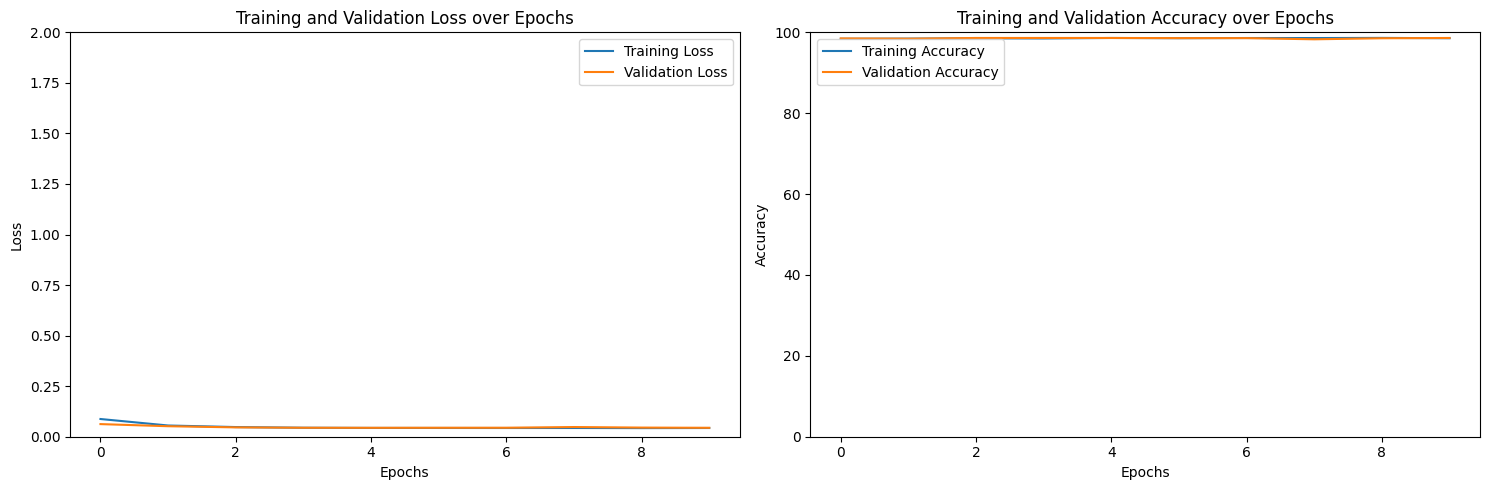

In [23]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(train_loss, label='Training Loss')

axs[0].plot(validation_loss, label='Validation Loss')

axs[0].set_title('Training and Validation Loss over Epochs')

axs[0].set_xlabel('Epochs')

axs[0].set_ylabel('Loss')

axs[0].set_ylim([0, 2])

axs[0].legend()


axs[1].plot(train_acc, label='Training Accuracy')

axs[1].plot(validation_acc, label='Validation Accuracy')

axs[1].set_title('Training and Validation Accuracy over Epochs')

axs[1].set_xlabel('Epochs')

axs[1].set_ylabel('Accuracy')

axs[1].set_ylim([0, 100])

axs[1].legend()

plt.tight_layout()

plt.show()